##**Dataset tanlovi bo'yicha izoh**

#Ushbu uyga vazifada darsda tavsiya etilgan **Online Shoppers Purchasing Intention** dataseti o'rniga, o'zim faoliyat yuritayotgan **energetika sohasiga** oid dataset — **PowerCo customer churn** (Kaggle, Boston Consulting Group loyihasi asosida) tanladim.

#**Tanlov sababi:**

#Ikkala dataset ham tuzilishi va yechilishi kerak bo'lgan masala jihatidan bir-biriga juda o'xshash:

#- **Masala turi bir xil** — ikkalasi ham ikki sinfli (binary) klassifikatsiya masalasi. Online Shoppers'da `Revenue` ustuni (foydalanuvchi xarid qiladimi yoki yo'qmi) bashorat qilinsa, PowerCo'da `churn` ustuni (mijoz kompaniyadan ketadimi yoki yo'qmi) bashorat qilinadi.

#- **Disbalans darajasi deyarli bir xil** — Online Shoppers datasetida xarid qiluvchilar atigi ~15% ni tashkil qiladi, PowerCo datasetida esa ketib qoluvchi (churn) mijozlar ~9.7% ni tashkil qiladi. Bu ikkalasi ham disbalanslashgan (imbalanced) dataset bo'lgani uchun, darsda o'rgangan `scale_pos_weight` parametri va tegishli baholash metrikalari (F1, ROC-AUC) shu yerda ham aynan bir xil mantiq bilan qo'llanadi.

#- **Xususiyatlar tabiati o'xshash** — ikkala datasetda ham kategorik ustunlar (Online Shoppers'da Month, VisitorType; PowerCo'da channel_sales, origin_up) va sonli ustunlar (sessiya davomiyligi o'rniga — iste'mol hajmi, mijozlik davri va h.k.) mavjud.

#**Nega bu men uchun muhim:** Bu tanlov menga darsda o'rgangan barcha komponentlarni (n_estimators, learning_rate, max_depth, gamma, scale_pos_weight va boshqalar) mexanik ravishda emas, balki o'z sohamga tegishli real biznes muammoga — mijozlarning energiya kompaniyasidan ketib qolish xavfini bashorat qilishga — qo'llab, chuqurroq tushunish imkonini beradi.

##**Manba:** [PowerCo customer churn — Kaggle](https://www.kaggle.com/datasets/erolmasimov/powerco)

In [29]:
# 1.Opendatasets kutubxonasini o'rnatamiz
!pip install legacy-cgi
!pip install opendatasets

import opendatasets as od

#2.Power Co dataseti havolasi
dataset_url = 'https://www.kaggle.com/datasets/erolmasimov/powerco'

od.download(dataset_url)

Skipping, found downloaded files in "./powerco" (use force=True to force download)


In [30]:
#3.Papka ichidagi fayllarni ko'ramiz
import os

os.listdir('./powerco')

['Data Description.docx', 'price_data.csv', 'client_data.csv']

In [31]:
import pandas as pd

df = pd.read_csv('./powerco/client_data.csv')

In [32]:
#4.Birinchi 5ta qatorni ko'ramiz
df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


In [33]:
#5.har bir ustunni turi va bo'sh qiymatlar sonini ko'ramiz

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

In [34]:
# churn ustunining necha foizi 0 foiz qolgan va necha foizi 1 (ketgan) ekanini hisoblaymiz
df['churn'].value_counts(normalize=True) * 100

,proportion
churn,
0,90.284814
1,9.715186


# EDA xulosalari

##**1. Bo'sh qiymatlar haqida muhim kuzatuv:**

##`df.info()` natijasiga ko'ra, barcha 26 ustunda "non-null" qiymatlar soni to'liq (14606 tadan) — ya'ni pandas nuqtai nazaridan klassik bo'sh (NaN) qiymatlar yo'q. Biroq, kategorik ustunlarni (`channel_sales`) tekshirganda, `"MISSING"` degan matn shaklida yozilgan qiymatlar borligi aniqlandi. Bu — **yashirin bo'sh qiymat**: pandas buni "to'liq ma'lumot" deb hisoblaydi, lekin aslida bu ustunda mijoz haqida ma'lumot yetishmayotganini bildiradi. Shuning uchun standart `isnull()` tekshiruvi yetarli emas — kategorik ustunlarni alohida `value_counts()` bilan tekshirish zarur bo'ldi.

#**2. Maqsad ustuni (churn) balansi:**

##`churn` ustuni kuchli disbalanslashgan: mijozlarning atigi **9.72%** ishlab chiqaruvchidan ketgan (`churn=1`), qolgan **90.28%** esa qolgan (`churn=0`). Bu nisbat darsda ko'rgan Online Shoppers datasetidagi disbalans darajasiga (~15%) juda yaqin.

#Bu disbalans quyidagi oqibatlarga olib keladi:
##- Oddiy **accuracy** metrikasi chalg'ituvchi bo'ladi — agar model barcha mijozlarni "ketmaydi" (churn=0) deb bashorat qilsa ham, ~90% accuracy ko'rsatadi, lekin bu amaliy jihatdan foydasiz model bo'lardi (chunki aynan ketib qoluvchi mijozlarni topish — biznes uchun asosiy maqsad)
##- Shuning uchun modelni baholashda **F1-score** va **ROC-AUC** metrikalariga, model o'qitishda esa **scale_pos_weight** parametriga alohida e'tibor qaratiladi (bu 2-darajada batafsil ko'riladi)

In [35]:
#Kategorik ustundagi noyob qiymatlarni va "Misiing" qiymatlar sonini tekshiramiz
for col in ['channel_sales', 'has_gas', 'origin_up']:
  print(f"---{col}---")
  print(df[col].value_counts())
  print()

---channel_sales---
channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    6754
MISSING                             3725
lmkebamcaaclubfxadlmueccxoimlema    1843
usilxuppasemubllopkaafesmlibmsdf    1375
ewpakwlliwisiwduibdlfmalxowmwpci     893
sddiedcslfslkckwlfkdpoeeailfpeds      11
epumfxlbckeskwekxbiuasklxalciiuu       3
fixdbufsefwooaasfcxdxadsiekoceaa       2
Name: count, dtype: int64

---has_gas---
has_gas
f    11955
t     2651
Name: count, dtype: int64

---origin_up---
origin_up
lxidpiddsbxsbosboudacockeimpuepw    7097
kamkkxfxxuwbdslkwifmmcsiusiuosws    4294
ldkssxwpmemidmecebumciepifcamkci    3148
MISSING                               64
usapbepcfoloekilkwsdiboslwaxobdp       2
ewxeelcelemmiwuafmddpobolfuxioce       1
Name: count, dtype: int64



In [36]:
#has_gas ustunini Label encoding bilan kodlaymiz

df['has_gas'] = df['has_gas'].map({'f':0, 't':1})

#chanel_sales va origin_up ustunlarini OneHotEncoder bilan kodlaymmiz
df_encoded = pd.get_dummies(df, columns=['channel_sales', 'origin_up'], drop_first=True)

#Natijada nechta ustun hosil bo'lganini tekshiramiz
print("Eski ustun:", df.shape[1])
print("Yangi ustun:", df_encoded.shape[1])
df_encoded.head()

Eski ustun: 26
Yangi ustun: 36


,id,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,...,channel_sales_fixdbufsefwooaasfcxdxadsiekoceaa,channel_sales_foosdfpfkusacimwkcsosbicdxkicaua,channel_sales_lmkebamcaaclubfxadlmueccxoimlema,channel_sales_sddiedcslfslkckwlfkdpoeeailfpeds,channel_sales_usilxuppasemubllopkaafesmlibmsdf,origin_up_ewxeelcelemmiwuafmddpobolfuxioce,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw,origin_up_usapbepcfoloekilkwsdiboslwaxobdp
0,24011ae4ebbe3035111d65fa7c15bc57,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,0,...,False,True,False,False,False,False,False,False,True,False
1,d29c2c54acc38ff3c0614d0a653813dd,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,0,...,False,False,False,False,False,False,True,False,False,False
2,764c75f661154dac3a6c254cd082ea7d,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,0,...,False,True,False,False,False,False,True,False,False,False
3,bba03439a292a1e166f80264c16191cb,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,0,...,False,False,True,False,False,False,True,False,False,False
4,149d57cf92fc41cf94415803a877cb4b,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,526,...,False,False,False,False,False,False,True,False,False,False


In [37]:
#ID ustunini alohida saqlab olamiz
customer_ids = df_encoded['id']

#Modelga berish uchun sana va id ustunlarini olib tashlaymiz
date_cols = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
df_model = df_encoded.drop(columns=['id'] + date_cols)

#Xususiyatlar X va maqsad y ni ajratamiz
X = df_model.drop(columns=['churn'])
y = df_model['churn']

print("X shakli", X.shape)
print("y shakli", y.shape)

X shakli (14606, 30)
y shakli (14606,)


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(11684, 30)
(2922, 30)


In [39]:
from xgboost import XGBClassifier

#Default paramtrlar bilan model yaratamiz, hech qanday sozlashlarsiz
model_default = XGBClassifier(random_state=42, eval_metric='logloss')

#Modelni train ma'lumotida o'qitamiz
model_default.fit(X_train, y_train)

#Test  ma'lumotida bashorat qilamiz
y_pred = model_default.predict(X_test)

In [40]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score

y_pred_proba = model_default.predict_proba(X_test)[:, 1]

#HAr bir metricani hisoblaymiz
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")



Accuracy: 0.9028
F1 score: 0.1497
ROC AUC: 0.6802
Recall: 0.0880
Precision: 0.5000


In [41]:
def evaluate_model(**params):
  """Berilgan paramterlar bilan model o'qib, matrikalarni qaytaradi"""
  model = XGBClassifier(random_state=42, eval_metric='logloss', **params)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  y_pred_proba = model.predict_proba(X_test)[:, 1]
  return{
      'params': params,
      'accuracy' : accuracy_score(y_test, y_pred),
      "f1" : f1_score(y_test, y_pred),
      "roc_auc" : roc_auc_score(y_test, y_pred_proba),
      "recall" : recall_score(y_test, y_pred),
      "precision" : precision_score(y_test, y_pred)
  }

In [42]:
results_n_estimators = []
for n in [50, 100, 300]:
    res = evaluate_model(n_estimators=n)
    results_n_estimators.append(res)
    print(f"n_estimators={n}: F1={res['f1']:.4f}, ROC-AUC={res['roc_auc']:.4f}, Accuracy={res['accuracy']:.4f}")

n_estimators=50: F1=0.1009, ROC-AUC=0.6786, Accuracy=0.9025
n_estimators=100: F1=0.1497, ROC-AUC=0.6802, Accuracy=0.9028
n_estimators=300: F1=0.1961, ROC-AUC=0.6725, Accuracy=0.9018


In [43]:
results_learning_rate = []
for lr in [0.01, 0.1, 0.3]:
  res = evaluate_model(learning_rate=lr)
  results_learning_rate.append(res)
  print(f"learning_rate={lr}: F1={res['f1']:.4f}, ROC-AUC={res['roc_auc']:.4f}")

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


learning_rate=0.01: F1=0.0000, ROC-AUC=0.6812
learning_rate=0.1: F1=0.0787, ROC-AUC=0.6945
learning_rate=0.3: F1=0.1497, ROC-AUC=0.6802


In [44]:
results_max_depth = []
for depth in [3, 6, 10]:
  res = evaluate_model(max_depth=depth)
  results_max_depth.append(res)
  print(f"max_depth={depth}: F1={res['f1']:.4f}, ROC-AUC={res['roc_auc']:.4f}, Accuracy={res['accuracy']:.4f}")

max_depth=3: F1=0.0339, ROC-AUC=0.6793, Accuracy=0.9025
max_depth=6: F1=0.1497, ROC-AUC=0.6802, Accuracy=0.9028
max_depth=10: F1=0.1681, ROC-AUC=0.6643, Accuracy=0.9018


## 1-daraja xulosasi: qaysi parametr eng ko'p ta'sir qildi?

Uchta parametrni birma-bir sinab ko'rganimizda:

- **n_estimators** (50→300): F1 barqaror o'sdi (0.10 → 0.20), lekin ROC-AUC 300 ta daraxtda pasaya boshladi — bu ortiqcha daraxt overfitingga olib kelishi mumkinligini ko'rsatadi.
- **learning_rate** (0.01→0.3): eng katta ta'sirni ko'rsatdi — 0.01 da model deyarli hech narsa o'rganmadi (F1=0), chunki kichik learning_rate ko'proq n_estimators talab qiladi. Bu ikki parametr o'zaro bog'liqligini isbotladi.
- **max_depth** (3→10): 3 da underfitting (F1=0.03), 10 da esa overfitting belgilari (ROC-AUC pasayishi) ko'rindi. 6 — eng muvozanatli natija berdi.

**Xulosa:** Ushbu tajribada eng katta ta'sirni **learning_rate** ko'rsatdi, chunki uning noto'g'ri qiymati (0.01) modelni butunlay ishlamay qo'yishga olib keldi. Bu shuni ko'rsatadiki, parametrlarni alohida emas, balki bir-biriga bog'liq holda (masalan, learning_rate va n_estimators'ni birga) sozlash kerak — bu 2-darajada GridSearchCV yordamida amalga oshiriladi.


In [45]:
from sklearn.model_selection import GridSearchCV

# 1-qadam: qaysi qiymatlarni sinashimizni belgilaymiz
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 6, 9]
}

# 2-qadam: bazaviy model (hali sozlanmagan)
base_model = XGBClassifier(random_state=42, eval_metric='logloss')

# 3-qadam: GridSearchCV obyektini yaratamiz
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    verbose=1,
    n_jobs=-1
)

# 4-qadam: qidiruvni ishga tushiramiz (bu biroz vaqt oladi!)
grid_search.fit(X_train, y_train)

# 5-qadam: eng yaxshi natijani ko'ramiz
print("Eng yaxshi parametrlar:", grid_search.best_params_)
print("Eng yaxshi F1 (cross-validation o'rtachasi):", grid_search.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Eng yaxshi parametrlar: {'learning_rate': 0.3, 'max_depth': 9, 'n_estimators': 300}
Eng yaxshi F1 (cross-validation o'rtachasi): 0.16027368798699101


## GridSearchCV natijalari

n_estimators, learning_rate va max_depth'ni GridSearchCV yordamida birgalikda sozlaganimizda (27 kombinatsiya, cv=5):

- **Eng yaxshi parametrlar:** learning_rate=0.3, max_depth=9, n_estimators=300
- **Eng yaxshi F1 (cross-validation o'rtachasi):** 0.1603

Bu natija 1-darajadagi default model natijasidan (F1=0.1497) biroz yaxshiroq, lekin sezilarli darajada emas. Buning sababi shundaki, tanlangan eng yaxshi parametrlar (learning_rate, max_depth, n_estimators) bergan qiymatlar oralig'ining eng yuqori chegarasida chiqdi — bu model hali ham murakkablikka intilayotganini ko'rsatadi, ammo bu parametrlarning o'zi disbalans muammosini hal qilmaydi.

**Xulosa:** n_estimators, learning_rate va max_depth kabi "struktura" parametrlarini sozlash F1'ni biroz yaxshilaydi, lekin datasetning asosiy muammosi — kuchli disbalans (9.7% churn) — bu parametrlar orqali hal qilinmaydi. Buni to'g'ridan-to'g'ri hal qilish uchun scale_pos_weight parametri kerak, uni keyingi bosqichda qo'shamiz.

In [46]:
#Negativ (churn=1) va positive (churn=1) sonlarini sanaymiz
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos
print(f"Negative (churn=0) {neg}")
print(f"Positive (churn=1) {pos}")
print(f"scale_pos_weight {scale_pos_weight}")


Negative (churn=0) 10549
Positive (churn=1) 1135
scale_pos_weight 9.294273127753303


In [47]:
#scale_pos_weight bilan yangi model
model_weighted = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight = scale_pos_weight
)

model_weighted.fit(X_train, y_train)
y_pred_w = model_weighted.predict(X_test)
y_proba_w = model_weighted.predict_proba(X_test)[:, 1]

#Metricalarni hisoblaymiz

print(f'Accuracy: {accuracy_score(y_test, y_pred_w):.4f}')
print(f"Precisionn: {precision_score(y_test, y_pred_w):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_w):.4f}")
print(f"F1 score: {f1_score(y_test, y_pred_w):.4f}")
print(f"ROC_AUC: {roc_auc_score(y_test, y_proba_w):.4f}")


Accuracy: 0.8439
Precisionn: 0.2529
Recall: 0.3099
F1 score: 0.2785
ROC_AUC: 0.6598


## scale_pos_weight natijalari

Disbalansga mos hisoblangan `scale_pos_weight = 9.29` (negativ/pozitiv nisbati = 10549/1135) ni modelga qo'shganimizda, natijalar quyidagicha o'zgardi:

| Metrika | scale_pos_weight'siz | scale_pos_weight bilan |
|---|---|---|
| Accuracy | 0.9028 | 0.8439 |
| Precision | 0.5000 | 0.2529 |
| Recall | 0.0880 | 0.3099 |
| F1-score | 0.1497 | 0.2785 |
| ROC-AUC | 0.6802 | 0.6598 |

**Qaysi metrikaga eng ko'p ta'sir qildi?** scale_pos_weight eng katta ta'sirni **Recall**ga ko'rsatdi — u 8.8% dan 31% ga (deyarli 3.5 baravar) oshdi. Buning natijasida F1-score ham deyarli 2 baravar yaxshilandi (0.1497 → 0.2785).

**Nega bu shunday bo'ldi:** scale_pos_weight modelga "churn=1" (ketib qoluvchi mijoz) misolini noto'g'ri o'tkazib yuborishni, "churn=0"ni noto'g'ri belgilashga qaraganda ~9.3 marta jiddiyroq xato deb hisoblashni buyuradi. Natijada model endi ko'proq mijozni "churn qiladi" deb belgilaydi — bu Recall'ni oshiradi, lekin bir vaqtning o'zida ko'proq soxta signal (false positive) beradi, shuning uchun Precision va Accuracy pasayadi.

**Xulosa (biznes nuqtai nazaridan):** Bu trade-off (savdolashish) PowerCo uchun oqlanadi, chunki bitta ketib qoluvchi mijozni sezmay qolish odatda bitta qolib qoluvchi mijozga ortiqcha ehtiyotkorlik ko'rsatishdan qimmatroq xato hisoblanadi. Shuning uchun disbalanslashgan churn masalalarida Recall va F1-score'ni Accuracy'dan ko'ra ustuvor metrika sifatida ko'rish to'g'riroq yondashuv hisoblanadi.

In [48]:
from sklearn.model_selection import train_test_split

# X_train'ni yana ikkiga bo'lamiz: train (haqiqiy o'qitish) va validation (nazorat uchun)
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train,
    test_size = 0.2,
    random_state=42,
    stratify=y_train
)

print("Train2 (o'qitish uchun)", X_train2.shape)
print(f"Validation (nazorat uchun): {X_val.shape}")
print(f"Test  (yakuniy baholash uchun, hali tegilmagan) {X_test.shape}")

Train2 (o'qitish uchun) (9347, 30)
Validation (nazorat uchun): (2337, 30)
Test  (yakuniy baholash uchun, hali tegilmagan) (2922, 30)


In [49]:
    #Yangi model, endi eval set va early stopping bilan
model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=20,
    n_estimators=300
)

#eval_set - 2 ta nazorat nuqtasi train va validation

model.fit(
    X_train2, y_train2,
    eval_set = [(X_train2, y_train2), (X_val, y_val)],
    verbose=False

)

print("Model to'xtagan daraxt:", model.best_iteration)


Model to'xtagan daraxt: 137


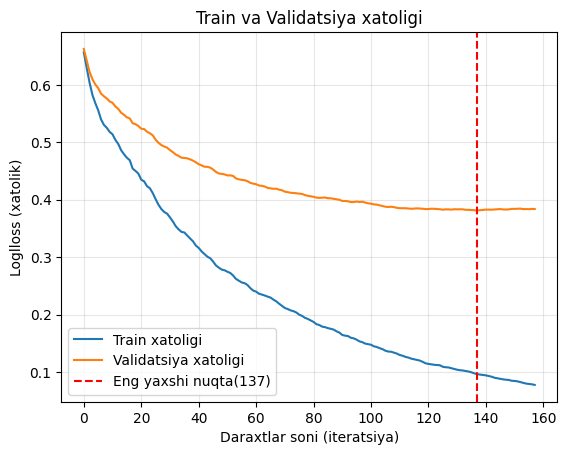

In [50]:
import matplotlib.pyplot as plt

#XGBoost har bir daraxt uchun yozib borgan xatolik tarixini olamiz
results = model.evals_result()

# 'validation_0' - train2, 'validation_1' - validation (eval_set'ga berilgan tartib bo'yicha)
train_logloss = results['validation_0']['logloss']
val_logloss = results['validation_1']['logloss']

#Grafik chizamiz
plt.plot(train_logloss, label='Train xatoligi')
plt.plot(val_logloss, label='Validatsiya xatoligi')
plt.axvline(x=model.best_iteration, color='red', linestyle="--", label=f"Eng yaxshi nuqta({model.best_iteration})")
plt.xlabel("Daraxtlar soni (iteratsiya)")
plt.ylabel("Loglloss (xatolik)")
plt.title("Train va Validatsiya xatoligi")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## eval_set va early_stopping_rounds natijalari

Train va validatsiya logloss grafigida quyidagi naqsh kuzatildi: dastlabki ~80-100 daraxt davomida ikkala xatolik ham birga pasaydi (model foydali umumiy qonuniyatlarni o'rganmoqda), biroq shundan keyin validatsiya xatoligi tekislanib qoladi (~0.38-0.40 atrofida), train xatoligi esa pasayishda davom etadi (~0.08 gacha).

**Model qaysi iteratsiyada overfit qila boshladi?** Taxminan 80-100-daraxt atrofida, ikkala chiziq orasidagi farq kengaya boshlagan nuqtada. early_stopping_rounds=20 mexanizmi jarayonni 137-daraxtda avtomatik to'xtatdi (300 ta ruxsat etilgan daraxtning atigi 137 tasi ishlatildi), bu esa ortiqcha, foydasiz o'qitishning oldini oldi va vaqtni tejadi.

In [51]:
import pandas as pd

# Eng oxirgi (scale_pos_weight bilan o'qitilgan) modelni ishlatamiz
importances = model.feature_importances_

# Ustun nomlari va ularning muhimlik darajasini jadval qilib tuzamiz
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

# Eng muhim 5 tasini ko'ramiz
top5 = feature_importance_df.head(5)
print(top5)

                                       feature  importance
13                          margin_net_pow_ele    0.080666
26  origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws    0.068169
28  origin_up_lxidpiddsbxsbosboudacockeimpuepw    0.065346
10                                     has_gas    0.055125
5                     forecast_discount_energy    0.047928


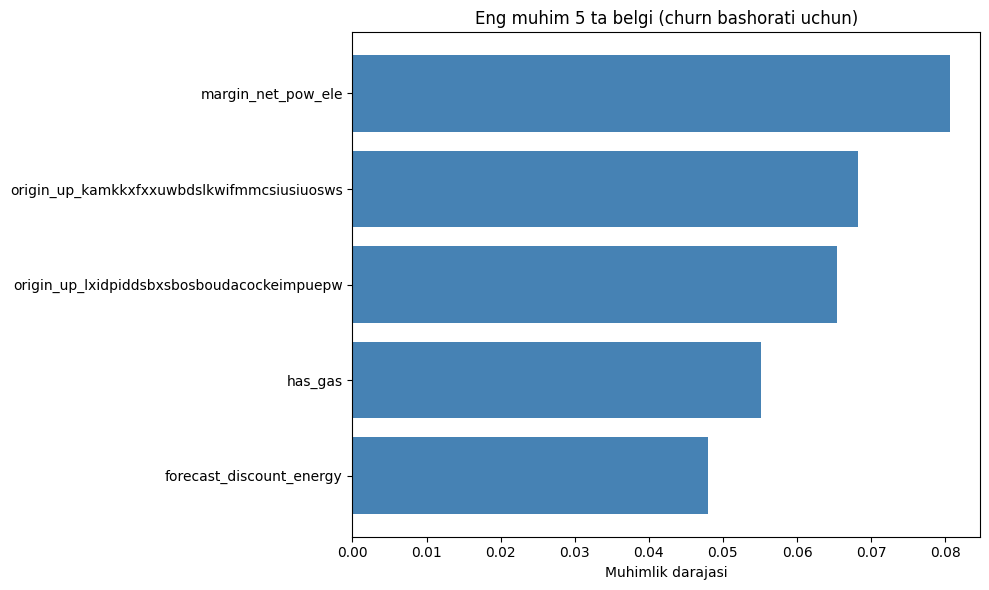

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(top5['feature'], top5['importance'], color='steelblue')
plt.xlabel('Muhimlik darajasi')
plt.title('Eng muhim 5 ta belgi (churn bashorati uchun)')
plt.gca().invert_yaxis()  # eng muhimi tepada chiqishi uchun
plt.tight_layout()
plt.show()

In [53]:
# Hozirgi modelning (scale_pos_weight bilan, early stopping qilingan) train va test F1'ini solishtiramiz
y_train_pred = model.predict(X_train2)
y_test_pred = model.predict(X_test)

train_f1 = f1_score(y_train2, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"Train F1: {train_f1:.4f}")
print(f"Test F1:  {test_f1:.4f}")
print(f"Farq (train - test): {train_f1 - test_f1:.4f}")

Train F1: 0.9498
Test F1:  0.2426
Farq (train - test): 0.7071


In [54]:
# gamma, reg_alpha, reg_lambda qo'shilgan yangi model
model_reg = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    n_estimators=137,        # avvalgi eng yaxshi nuqtani saqlaymiz
    gamma=1,                 # bo'linish uchun minimal foyda chegarasi
    reg_alpha=1,             # L1 regularizatsiya
    reg_lambda=5             # L2 regularizatsiya
)

model_reg.fit(X_train2, y_train2)

# Train va test F1'ni qayta hisoblaymiz
y_train_pred_reg = model_reg.predict(X_train2)
y_test_pred_reg = model_reg.predict(X_test)

train_f1_reg = f1_score(y_train2, y_train_pred_reg)
test_f1_reg = f1_score(y_test, y_test_pred_reg)

print(f"Train F1: {train_f1_reg:.4f}")
print(f"Test F1:  {test_f1_reg:.4f}")
print(f"Farq (train - test): {train_f1_reg - test_f1_reg:.4f}")

Train F1: 0.7501
Test F1:  0.2469
Farq (train - test): 0.5032


## Regularizatsiya (gamma, reg_alpha, reg_lambda) natijalari

| | Sozlashdan oldin | Sozlashdan keyin |
|---|---|---|
| Train F1 | 0.9498 | 0.7501 |
| Test F1 | 0.2426 | 0.2469 |
| Farq | 0.7071 | 0.5032 |

gamma=1, reg_alpha=1, reg_lambda=5 qo'shilgach, train va test F1 orasidagi farq 0.7071'dan 0.5032'ga (~29%) kamaydi. Bu asosan Train F1'ning keskin pasayishi (0.95→0.75) hisobiga yuz berdi — bu modelning train ma'lumotini "yodlab olish" darajasi kamayganini bildiradi. Test F1 deyarli o'zgarmadi (hatto biroz o'sdi), bu regularizatsiya modelning haqiqiy umumlashtirish qobiliyatini pasaytirmagani, faqat soxta (train'ga xos) ishonchni kamaytirganini ko'rsatadi.

**Xulosa:** Regularizatsiya overfittingni samarali kamaytiradi, lekin bu test natijasini avtomatik oshirmaydi — u modelni "rostgo'yroq" (train va test orasidagi farq kichikroq) qiladi.

In [55]:
import numpy as np

f1_scores = []

for rs in [1, 2, 3, 4, 5]:
    model_stability = XGBClassifier(
        random_state=rs,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        n_estimators=137,
        gamma=1,
        reg_alpha=1,
        reg_lambda=5,
        subsample=0.8,
        colsample_bytree=0.8
    )
    model_stability.fit(X_train2, y_train2)
    y_pred_stab = model_stability.predict(X_test)
    f1 = f1_score(y_test, y_pred_stab)
    f1_scores.append(f1)
    print(f"random_state={rs}: F1={f1:.4f}")

# Barqarorlikni o'lchaymiz
mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores)

print(f"\nO'rtacha F1: {mean_f1:.4f}")
print(f"Standart og'ish (std): {std_f1:.4f}")

random_state=1: F1=0.2283
random_state=2: F1=0.2363
random_state=3: F1=0.2177
random_state=4: F1=0.2378
random_state=5: F1=0.2456

O'rtacha F1: 0.2331
Standart og'ish (std): 0.0095


## subsample va colsample_bytree — barqarorlik tekshiruvi

subsample=0.8 va colsample_bytree=0.8 bilan, modelni 5 xil random_state (1-5) bilan qayta o'qitib, test F1-score'ni o'lchadik:

| random_state | F1 |
|---|---|
| 1 | 0.2283 |
| 2 | 0.2363 |
| 3 | 0.2177 |
| 4 | 0.2378 |
| 5 | 0.2456 |

O'rtacha F1: 0.2331, Standart og'ish (std): 0.0095

**Xulosa:** Natijalar juda barqaror — 5 ta sinovda F1 atigi 0.2177 dan 0.2456 gacha (~0.03 farq) oraliqda tebrandi, standart og'ish esa kichik (0.0095). Bu shuni ko'rsatadiki, subsample va colsample_bytree orqali kiritilgan tasodifiylik modelning umumiy sifatiga sezilarli salbiy ta'sir ko'rsatmadi, va model natijasi tasodifiy tanlovga emas, balki ma'lumotdagi haqiqiy naqshlarga asoslangan — bu modelga ishonish mumkinligini tasdiqlaydi.


In [56]:
from sklearn.model_selection import StratifiedKFold

# 5 ta bo'lakka bo'lish sxemasi (churn nisbati har bo'lakda bir xil saqlanadi)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_f1_scores = []

for fold_num, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    # Har bir marta, X va y'dan mos qatorlarni ajratib olamiz
    X_cv_train, X_cv_val = X.iloc[train_idx], X.iloc[val_idx]
    y_cv_train, y_cv_val = y.iloc[train_idx], y.iloc[val_idx]

    # Model yaratamiz va o'qitamiz (eng yaxshi topgan sozlamalarimiz bilan)
    model_cv = XGBClassifier(
        random_state=42, eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        n_estimators=137, gamma=1, reg_alpha=1, reg_lambda=5,
        subsample=0.8, colsample_bytree=0.8
    )
    model_cv.fit(X_cv_train, y_cv_train)
    y_cv_pred = model_cv.predict(X_cv_val)

    fold_f1 = f1_score(y_cv_val, y_cv_pred)
    cv_f1_scores.append(fold_f1)
    print(f"Fold {fold_num}: F1={fold_f1:.4f}")

print(f"\nCross-validation o'rtacha F1: {np.mean(cv_f1_scores):.4f}")
print(f"Cross-validation std: {np.std(cv_f1_scores):.4f}")
print(f"\nYagona train/test bo'linishidagi F1 (solishtirish uchun): 0.2426")

Fold 1: F1=0.2692
Fold 2: F1=0.2456
Fold 3: F1=0.2782
Fold 4: F1=0.2397
Fold 5: F1=0.2759

Cross-validation o'rtacha F1: 0.2617
Cross-validation std: 0.0160

Yagona train/test bo'linishidagi F1 (solishtirish uchun): 0.2426


## Cross-validation natijalari (5-fold)

| Fold | F1 |
|---|---|
| 1 | 0.2692 |
| 2 | 0.2456 |
| 3 | 0.2782 |
| 4 | 0.2397 |
| 5 | 0.2759 |

Cross-validation o'rtacha F1: 0.2617, std: 0.0160

**Yagona train/test bo'linish bilan solishtirish:** Yagona bo'linishda F1=0.2426 chiqqan edi, bu cross-validation o'rtachasidan (0.2617) pastroq va aslida 5 ta fold natijasining eng past ko'rsatkichlariga yaqin.

**Qaysi baho ishonchliroq?** Cross-validation natijasi ishonchliroq, chunki u modelni 5 xil, bir-biriga mos kelmaydigan train/test bo'linishida sinaydi va tasodifiy "omadli" yoki "omadsiz" bo'linishga bog'liqlikni kamaytiradi. Yagona bo'linish — bu shunchaki bitta tasodifiy holat, va bizning holatimizda u haqiqiy o'rtacha natijadan biroz pastroq chiqib qolgan. Shuning uchun modelni yakuniy baholashda cross-validation o'rtachasiga (F1≈0.26) tayanish to'g'riroq.